In [1]:
from google.colab import files

In [2]:
files.upload()

Saving data_set_test.csv to data_set_test.csv


{'data_set_test.csv': b'\xef\xbb\xbfJurusan,Matematika,Bahasa Inggris,Bahasa Indonesia,Prestasi Siswa,Prestasi Sekolah\r\nMatematika,92,86,88,1,1\r\nMatematika,84,82,88,1,1\r\nSastra Inggris,83,88,81,2,2\r\nSastra Indonesia,82,85,84,2,1\r\nSastra Inggris,83,85,84,1,1\r\nSastra Indonesia,88,82,88,1,1\r\n'}

In [3]:
files.upload()

Saving data_testing.csv to data_testing.csv


{'data_testing.csv': b'\xef\xbb\xbfJurusan,Matematika,Bahasa Inggris,Bahasa Indonesia,Prestasi Siswa,Prestasi Sekolah\r\nMatematika,92,86,88,1,1\r\nMatematika,90,86,85,1,2\r\nSastra Inggris,82,87,92,2,1\r\nMatematika,93,82,85,1,1\r\nSastra Inggris,86,85,88,1,1\r\nMatematika,91,83,84,2,2\r\nSastra Indonesia,88,80,90,2,1\r\nSastra Indonesia,84,82,88,1,1\r\nSastra Inggris,79,89,85,1,1\r\nSastra Inggris,83,88,81,2,2\r\nSastra Inggris,82,85,84,2,1\r\n'}

In [4]:
import pandas as pd

In [5]:
sh1 = pd.read_csv('data_set_test.csv')

In [6]:
sh2 = pd.read_csv('data_testing.csv')

In [7]:
gabung = pd.concat([sh1, sh2], ignore_index=True)

In [8]:
print(gabung.shape)

(17, 6)


In [9]:
gabung.head()

,Jurusan,Matematika,Bahasa Inggris,Bahasa Indonesia,Prestasi Siswa,Prestasi Sekolah
0,Matematika,92,86,88,1,1
1,Matematika,84,82,88,1,1
2,Sastra Inggris,83,88,81,2,2
3,Sastra Indonesia,82,85,84,2,1
4,Sastra Inggris,83,85,84,1,1


In [10]:
gabung.head(20)

,Jurusan,Matematika,Bahasa Inggris,Bahasa Indonesia,Prestasi Siswa,Prestasi Sekolah
0,Matematika,92,86,88,1,1
1,Matematika,84,82,88,1,1
2,Sastra Inggris,83,88,81,2,2
3,Sastra Indonesia,82,85,84,2,1
4,Sastra Inggris,83,85,84,1,1
5,Sastra Indonesia,88,82,88,1,1
6,Matematika,92,86,88,1,1
7,Matematika,90,86,85,1,2
8,Sastra Inggris,82,87,92,2,1
9,Matematika,93,82,85,1,1


In [11]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

In [12]:
print('\nStatistik singkat per kolom nilai')


Statistik singkat per kolom nilai


In [13]:
print(gabung[['Matematika','Bahasa Inggris','Bahasa Indonesia']].describe())

       Matematika  Bahasa Inggris  Bahasa Indonesia
count   17.000000       17.000000         17.000000
mean    86.000000       84.764706         86.058824
std      4.344537        2.562455          3.009788
min     79.000000       80.000000         81.000000
25%     83.000000       82.000000         84.000000
50%     84.000000       85.000000         85.000000
75%     90.000000       86.000000         88.000000
max     93.000000       89.000000         92.000000


In [14]:
by_jur = gabung.groupby('Jurusan').mean(numeric_only=True)

In [15]:
print('\nRata‑rata per Jurusan')


Rata‑rata per Jurusan


In [16]:
print(by_jur)

                  Matematika  Bahasa Inggris  Bahasa Indonesia  \
Jurusan                                                          
Matematika         90.333333       84.166667         86.333333   
Sastra Indonesia   85.500000       82.250000         87.500000   
Sastra Inggris     82.571429       86.714286         85.000000   

                  Prestasi Siswa  Prestasi Sekolah  
Jurusan                                             
Matematika              1.166667          1.333333  
Sastra Indonesia        1.500000          1.000000  
Sastra Inggris          1.571429          1.285714  


In [18]:
import matplotlib.pyplot as plt

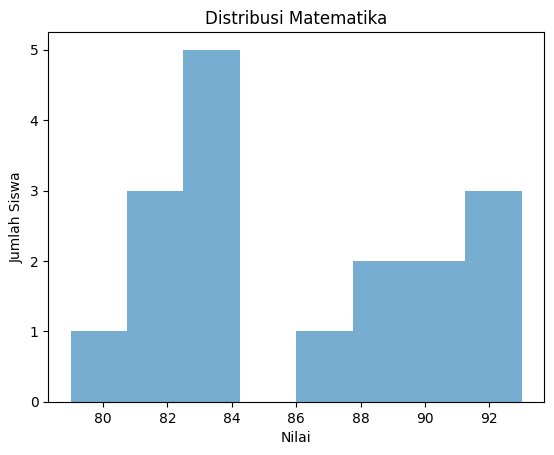

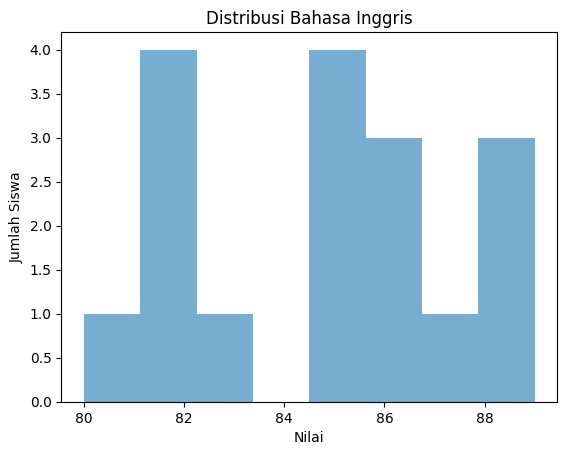

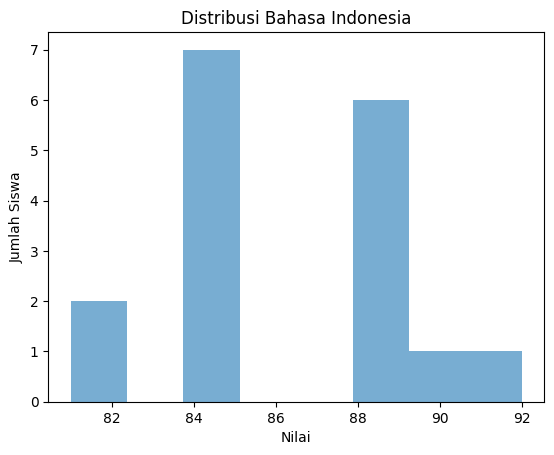

In [19]:
for col in ['Matematika', 'Bahasa Inggris', 'Bahasa Indonesia']:
    gabung[col].plot(kind='hist', bins=8, alpha=.6, title=f'Distribusi {col}')
    plt.xlabel('Nilai')
    plt.ylabel('Jumlah Siswa')
    plt.show()

In [20]:
import seaborn as sns

In [21]:
import matplotlib.pyplot as plt

In [22]:
plt.figure(figsize=(6,4))

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Axes: >

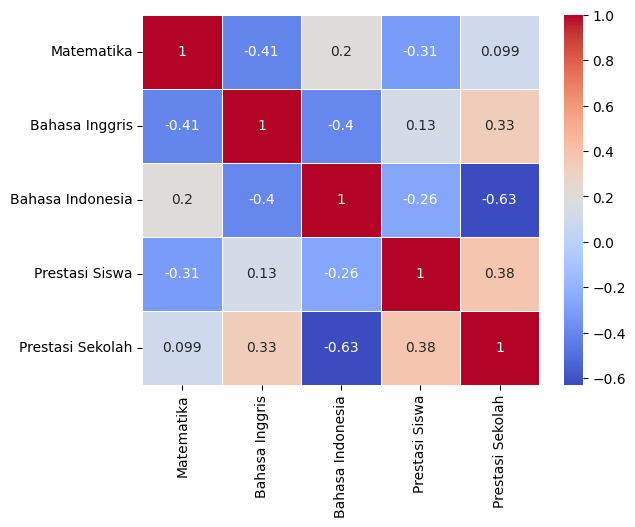

In [23]:
sns.heatmap(
    gabung[['Matematika','Bahasa Inggris','Bahasa Indonesia',
            'Prestasi Siswa','Prestasi Sekolah']].corr(),
    annot=True, linewidths=.5, cmap='coolwarm')

Text(0.5, 1.0, 'Korelasi Nilai & Prestasi')

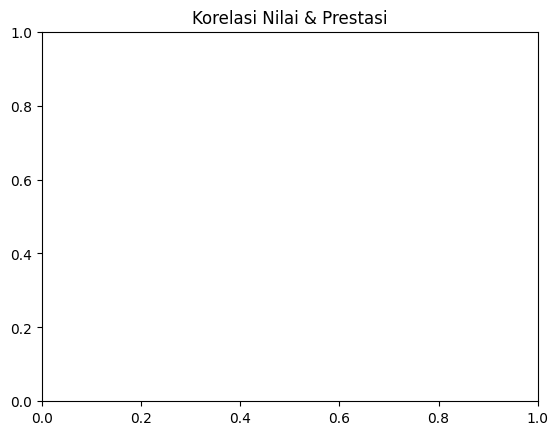

In [24]:
plt.title('Korelasi Nilai & Prestasi')

In [25]:
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [28]:
from sklearn.metrics import classification_report

In [29]:
X = pd.get_dummies(gabung[['Jurusan','Matematika',
                           'Bahasa Inggris','Bahasa Indonesia']],
                   columns=['Jurusan'])
y = gabung['Prestasi Siswa']

In [30]:
x_tr, x_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=82)

In [31]:
dtree = DecisionTreeClassifier(random_state=82).fit(x_tr, y_tr)

In [32]:
print(classification_report(y_te, dtree.predict(x_te)))

              precision    recall  f1-score   support

           1       1.00      0.75      0.86         4
           2       0.00      0.00      0.00         0

    accuracy                           0.75         4
   macro avg       0.50      0.38      0.43         4
weighted avg       1.00      0.75      0.86         4



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
x_tr, x_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=82, stratify=y)

In [34]:
dtree = DecisionTreeClassifier(random_state=82)
dtree.fit(x_tr, y_tr)

DecisionTreeClassifier(random_state=82)

In [35]:
y_pred = dtree.predict(x_te)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_te, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [37]:
print('\nConfusion matrix:')
print(confusion_matrix(y_te, y_pred))


Confusion matrix:
[[1 1]
 [0 2]]


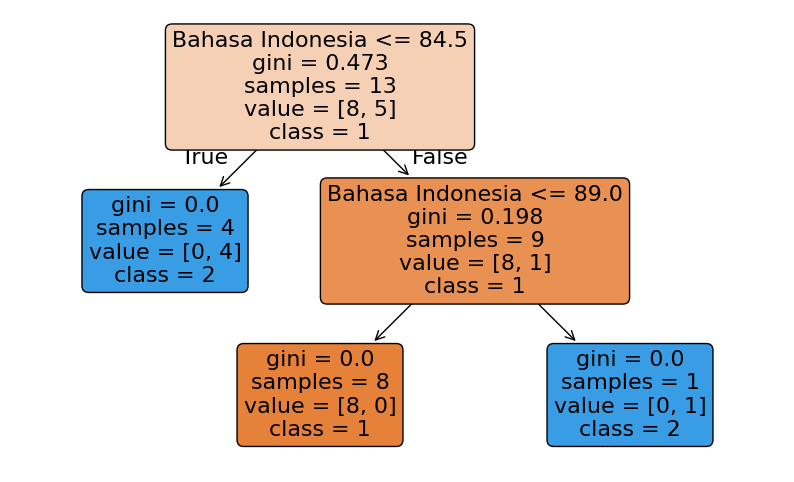

In [38]:
plt.figure(figsize=(10,6))
plot_tree(dtree, feature_names=x_tr.columns, class_names=['1','2'], filled=True, rounded=True)
plt.show()